<a href="https://colab.research.google.com/github/wawaelenti/Machine-Learning/blob/main/KMeans_Cosine_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📐 1. Formulasi Matematis Cosine Similarity & Fungsi Objektif

### 1.1. Cosine Similarity dan Cosine Distance
Kemiripan arah dua vektor non-nol dihitung dengan:
$$s_{\mathrm{Cosine}}(x,y)=\frac{x\cdot y}{\lVert x\rVert_2\lVert y\rVert_2},
\qquad d_{\mathrm{Cosine}}(x,y)=1-s_{\mathrm{Cosine}}(x,y).$$
Normalisasi L2 menghasilkan vektor satuan $z=x/\lVert x\rVert_2$.
Untuk dua vektor satuan berlaku:
$$\lVert z-w\rVert_2^2=2\bigl(1-s_{\mathrm{Cosine}}(z,w)\bigr).$$

### 1.2. Fungsi Objektif Implementasi
Notebook mempertahankan `KMeans` pada data setelah StandardScaler dan
normalisasi L2, dengan centroid berupa rata-rata anggota klaster:
$$J_{\mathrm{KMeans}}=\sum_{j=1}^{K}\sum_{z\in S_j}\lVert z-\mu_j\rVert_2^2.$$
Cosine similarity dipakai untuk menganalisis kedekatan data ke centroid;
Silhouette Score dievaluasi dengan cosine distance. Centroid hasil `KMeans`
tidak dinormalisasi ulang. Semua baris dataset digunakan dan PCA diterapkan
untuk visualisasi.

In [ ]:
# =======================================================================
# 1. SETUP & IMPORT LIBRARY
# =======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120


In [ ]:
# =======================================================================
# 2. DATASET & PREPROCESSING
# =======================================================================
FILE = 'dataset_B_05_2020 (1).csv'
df = pd.read_csv(FILE)

print('Shape dataset:', df.shape)
print('Jumlah data:', df.shape[0])
print('Jumlah kolom:', df.shape[1])
display(df.head(3))

# Metadata dan label asli disimpan terpisah dari fitur clustering.
urls = df['url'].copy()
y_true = df['status'].copy()
labels = y_true.copy()
X = df.drop(columns=['url', 'status']).select_dtypes(include=np.number)
print('Shape fitur numerik:', X.shape)

# Imputasi median, penghapusan fitur konstan, lalu StandardScaler.
print('Missing value sebelum imputasi:', int(X.isna().sum().sum()))
X = X.fillna(X.median())
print('Missing value setelah imputasi:', int(X.isna().sum().sum()))

selector = VarianceThreshold(threshold=0)
X_sel = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()]
removed_features = X.columns[~selector.get_support()]
X_selected = pd.DataFrame(X_sel, columns=selected_features, index=X.index)
print('Fitur konstan yang dihapus:', list(removed_features))
print('Shape setelah seleksi fitur:', X_selected.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
df_after = pd.DataFrame(X_scaled, columns=selected_features, index=X.index)
print('Shape setelah StandardScaler:', X_scaled.shape)
display(df_after.head(3))

# Normalisasi L2 digunakan oleh varian K-Means Cosine.
X_cosine = normalize(X_scaled, norm='l2')
print('Shape setelah normalisasi L2:', X_cosine.shape)


Shape dataset: (11430, 89)
Jumlah data: 11430
Jumlah kolom: 89


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing


Shape fitur numerik: (11430, 87)
Missing value sebelum imputasi: 0
Missing value setelah imputasi: 0
Fitur konstan yang dihapus: ['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection', 'ratio_intErrors', 'submit_email', 'sfh']
Shape setelah seleksi fitur: (11430, 81)
Shape setelah StandardScaler: (11430, 81)


,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,nb_underscore,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
0,-0.436327,-0.193964,-0.421020,0.379116,-0.477984,-0.142915,-0.387464,-0.197604,-0.293683,-0.295128,...,-0.377549,-1.860473,1.129194,-0.28037,-0.549299,-1.307594,-0.429340,6.978227,0.934264,0.320974
1,0.287067,0.177207,2.375182,-1.081136,-0.477984,-0.142915,-0.387464,-0.197604,-0.293683,-0.295128,...,-0.377549,0.537498,-0.885587,-0.28037,-0.510022,0.548471,-0.429340,-0.143303,0.934264,-0.467407
2,1.173224,2.682613,2.375182,1.109242,0.001174,-0.142915,2.356473,2.237556,2.711505,1.534217,...,-0.377549,0.537498,-0.885587,-0.28037,-0.587348,-0.018839,2.491612,-0.143303,0.934264,-1.255788


Shape setelah normalisasi L2: (11430, 81)


## 📈 2. Evaluasi Jumlah Klaster Menggunakan Cosine Similarity

Rata-rata cosine similarity dihitung untuk $k=2,\ldots,10$:
$$\overline{s}(k)=\frac{1}{n}\sum_{i=1}^{n}
s_{\mathrm{Cosine}}(z_i,\mu_{c(i)}).$$
Notebook mempertahankan pilihan model akhir `K_OPTIMAL = 3`.
Kurva menunjukkan perubahan similarity dan menandai nilai $k$ yang digunakan;
nilai ini merupakan parameter yang dipilih pada notebook awal.

Menjalankan K-Means untuk K=2...
K=2 | Mean Cosine Similarity=0.2654
Menjalankan K-Means untuk K=3...


K=3 | Mean Cosine Similarity=0.3461
Menjalankan K-Means untuk K=4...
K=4 | Mean Cosine Similarity=0.3912
Menjalankan K-Means untuk K=5...


K=5 | Mean Cosine Similarity=0.4255
Menjalankan K-Means untuk K=6...


K=6 | Mean Cosine Similarity=0.4482
Menjalankan K-Means untuk K=7...


K=7 | Mean Cosine Similarity=0.4630
Menjalankan K-Means untuk K=8...


K=8 | Mean Cosine Similarity=0.4763
Menjalankan K-Means untuk K=9...


K=9 | Mean Cosine Similarity=0.4871
Menjalankan K-Means untuk K=10...


K=10 | Mean Cosine Similarity=0.4991


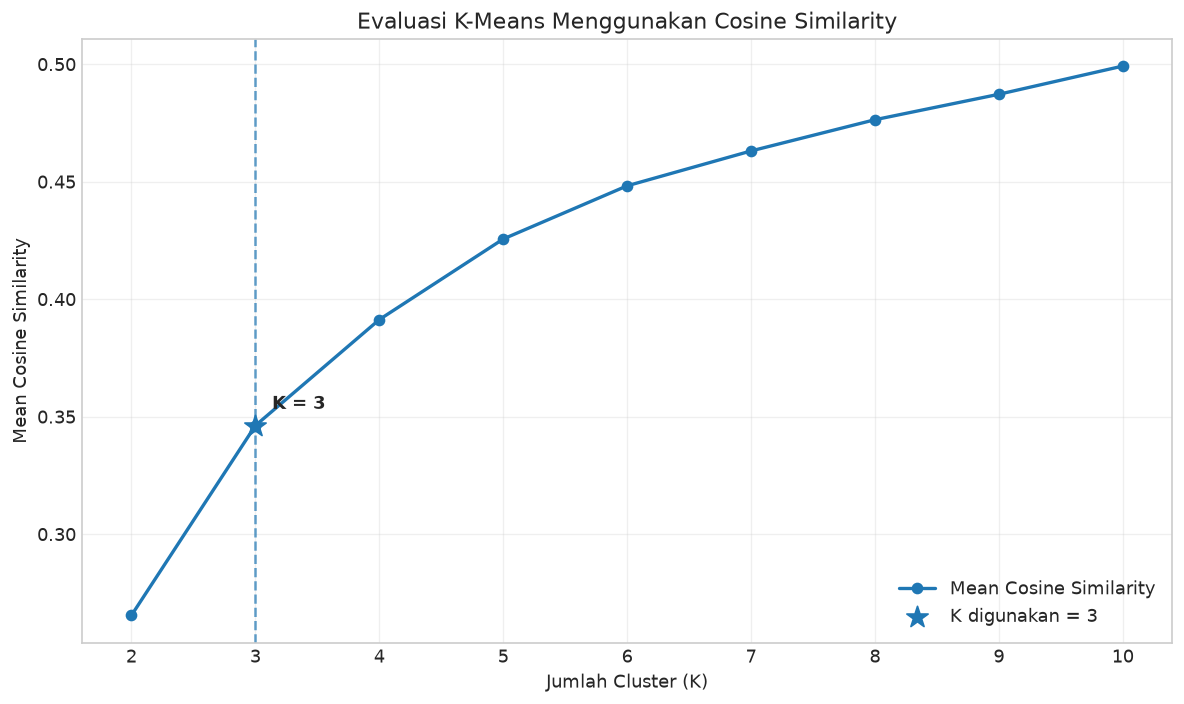

In [ ]:
# =======================================================================
# 3. EVALUASI COSINE SIMILARITY UNTUK JUMLAH KLASTER
# =======================================================================
K_range = range(2, 11)

cosine_similarity_scores = []

for k in K_range:

    print(f"Menjalankan K-Means untuk K={k}...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_k = kmeans.fit_predict(X_cosine)

    # Cosine similarity data terhadap seluruh centroid
    similarities = cosine_similarity(
        X_cosine,
        kmeans.cluster_centers_
    )

    # Ambil similarity terhadap centroid cluster masing-masing data
    assigned_similarity = similarities[
        np.arange(len(X_cosine)),
        labels_k
    ]

    # Rata-rata similarity
    mean_similarity = assigned_similarity.mean()

    cosine_similarity_scores.append(
        mean_similarity
    )

    print(
        f"K={k} | "
        f"Mean Cosine Similarity={mean_similarity:.4f}"
    )

K_OPTIMAL = 3
optimal_k_cosine = K_OPTIMAL
optimal_index = list(K_range).index(optimal_k_cosine)

plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    cosine_similarity_scores,
    marker="o",
    linewidth=2,
    label="Mean Cosine Similarity"
)

plt.scatter(
    optimal_k_cosine,
    cosine_similarity_scores[optimal_index],
    s=180,
    marker="*",
    zorder=5,
    label=f"K digunakan = {optimal_k_cosine}"
)

plt.axvline(
    optimal_k_cosine,
    linestyle="--",
    alpha=0.7
)

plt.annotate(
    f"K = {optimal_k_cosine}",
    xy=(
        optimal_k_cosine,
        cosine_similarity_scores[optimal_index]
    ),
    xytext=(10, 10),
    textcoords="offset points",
    fontweight="bold"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Mean Cosine Similarity")
plt.title("Evaluasi K-Means Menggunakan Cosine Similarity")

plt.xticks(list(K_range))
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# =======================================================================
# 4. KONFIGURASI MODEL K-MEANS COSINE
# =======================================================================
kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)


In [ ]:
# =======================================================================
# 5. EKSEKUSI CLUSTERING & METRIK EVALUASI
# =======================================================================
cluster_labels = kmeans_final.fit_predict(X_cosine)
silhouette_cosine = silhouette_score(X_cosine, cluster_labels, metric='cosine')
assigned_similarity = cosine_similarity(X_cosine, kmeans_final.cluster_centers_)[np.arange(len(X_cosine)), cluster_labels]

eval_df = pd.DataFrame([{
    'Distance Metric': 'Cosine (data L2)',
    'K yang Digunakan': K_OPTIMAL,
    'Jumlah Klaster': len(np.unique(cluster_labels)),
    'Silhouette Score': silhouette_cosine,
    'Mean Cosine Similarity': assigned_similarity.mean(),
    'Objective Value (SSE pada Data L2)': kmeans_final.inertia_,
    'Iterations': kmeans_final.n_iter_,
}])
display(eval_df.round(4))
print('Distribusi klaster:')
display(pd.Series(cluster_labels, name='Cluster').value_counts().sort_index().to_frame('Jumlah Data'))


,Distance Metric,K yang Digunakan,Jumlah Klaster,Silhouette Score,Mean Cosine Similarity,Objective Value (SSE pada Data L2),Iterations
0,Cosine (data L2),3,3,0.1286,0.3461,10010.0346,12


Distribusi klaster:


,Jumlah Data
Cluster,
0,4488
1,4128
2,2814


Explained variance ratio:
[0.09903713 0.07858374]
Total variance 2D: 0.177620870703164


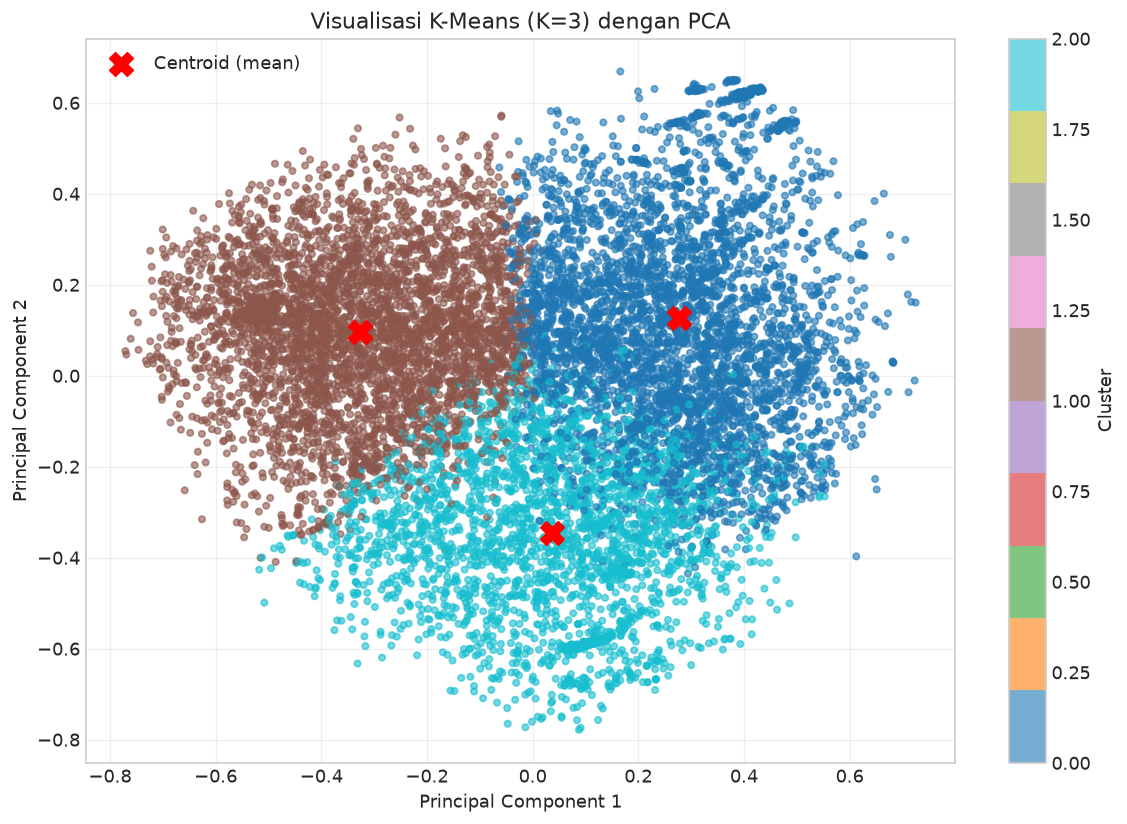

In [ ]:
# =======================================================================
# 6. VISUALISASI PCA 2D PEMETAAN KLASTER & CENTROIDS
# =======================================================================
pca_vis = PCA(n_components=2, svd_solver="full", random_state=RANDOM_STATE)

X_2d = pca_vis.fit_transform(X_cosine)

print("Explained variance ratio:")
print(pca_vis.explained_variance_ratio_)

print(
    "Total variance 2D:",
    pca_vis.explained_variance_ratio_.sum()
)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=15,
    alpha=0.6
)

centroids_2d = pca_vis.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], c='red', marker='X', s=200, label='Centroid (mean)')
plt.legend()
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(
    f"Visualisasi K-Means (K={K_OPTIMAL}) "
    "dengan PCA"
)

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
